In [1]:
!git clone https://github.com/ultralytics/yolov5
%pip install -qr yolov5/requirements.txt

import os
import torch

Cloning into 'yolov5'...
remote: Enumerating objects: 13017, done.
remote: Counting objects: 100% (192/192), done.
remote: Compressing objects: 100% (86/86), done.
remote: Total 13017 (delta 118), reused 174 (delta 106), pack-reused 12825
Receiving objects: 100% (13017/13017), 12.39 MiB | 20.01 MiB/s, done.
Resolving deltas: 100% (8946/8946), done.
Note: you may need to restart the kernel to use updated packages.


In [2]:
model = torch.hub.load('ultralytics/yolov5', 'yolov5s')
model_classes = model.names

Downloading: "https://github.com/ultralytics/yolov5/archive/master.zip" to /root/.cache/torch/hub/master.zip
YOLOv5 🚀 2022-7-22 Python-3.7.12 torch-1.11.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)



  0%|          | 0.00/14.1M [00:00<?, ?B/s]


Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients
Adding AutoShape... 


In [3]:
from urllib.request import urlretrieve
src = 'https://v16-webapp.tiktok.com/9fc3199bba9ca79a293ec06bdca4f9f4/62db6168/video/tos/useast2a/tos-useast2a-pve-0037-aiso/25557467ccd94e04b719e83ed5aaa2bd/?a=1988&ch=0&cr=0&dr=0&lr=tiktok_m&cd=0%7C0%7C1%7C0&cv=1&br=2598&bt=1299&btag=80000&cs=0&ds=3&ft=eXd.6Hm9Myq8ZHpHnwe2NBPhml7Gb&mime_type=video_mp4&qs=0&rc=PGQ1PGg6ODk8NDZkOjlmN0BpM25sPDM6ZnRvPDMzZjczM0BeMS9fL2MwXzAxLzRjMi00YSNqMmVmcjRvNGJgLS1kMWNzcw%3D%3D&l=202207222047450102452421970A1E2B12'
_ = urlretrieve(src, 'example.mp4')

In [4]:
VIDEO = 'example.mp4'          # video example for analysis
DETECT = 'yolov5/detect.py'    # path to Yolo detect.py
IMG_WIDTH = 200                # compreesing video to speed up calculations
CONFIDENCE = 0.4               # confidence threashold for object detection #0.25 - standart
NUMBER_OF_APPEARANCES = 50     # an object describe the video if it appears in more than 50 frames (= 2 sec)
PROJECT = 'example_project'    # progect directory to save result
NAME = 'example'               # progect directory to save result

In [5]:
from IPython.display import HTML
from base64 import b64encode

def play(filename):
    html = ''
    video = open(filename,'rb').read()
    src = 'data:video/mp4;base64,' + b64encode(video).decode()
    html += '<video width=330 controls autoplay loop><source src="%s" type="video/mp4"></video>' % src 
    return HTML(html)

play(VIDEO)

In [6]:
!python $DETECT --source $VIDEO --save-txt --img $IMG_WIDTH --project $PROJECT --name $NAME --conf-thres $CONFIDENCE

detect: weights=yolov5/yolov5s.pt, source=example.mp4, data=yolov5/data/coco128.yaml, imgsz=[200, 200], conf_thres=0.4, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=True, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=example_project, name=example, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
YOLOv5 🚀 v6.1-312-gb92430a Python-3.7.12 torch-1.11.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

100%|███████████████████████████████████████| 14.1M/14.1M [00:00<00:00, 163MB/s]

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients
video 1/1 (1/591) /kaggle/working/example.mp4: 224x128 1 person, 1 chair, 1 potted plant, Done. (0.010s)
video 1/1 (2/591) /kaggle/working/example.mp4: 224x128 1 person, 1 chair, 1 potted plant, Done. (0.011s)
video 1/1 (3/591) /kaggle/working/example.mp4: 224x128 1 person, 1 chair, 1 potted pl

In [7]:
!python $DETECT --help

usage: detect.py [-h] [--weights WEIGHTS [WEIGHTS ...]] [--source SOURCE]
                 [--data DATA] [--imgsz IMGSZ [IMGSZ ...]]
                 [--conf-thres CONF_THRES] [--iou-thres IOU_THRES]
                 [--max-det MAX_DET] [--device DEVICE] [--view-img]
                 [--save-txt] [--save-conf] [--save-crop] [--nosave]
                 [--classes CLASSES [CLASSES ...]] [--agnostic-nms]
                 [--augment] [--visualize] [--update] [--project PROJECT]
                 [--name NAME] [--exist-ok] [--line-thickness LINE_THICKNESS]
                 [--hide-labels] [--hide-conf] [--half] [--dnn]

optional arguments:
  -h, --help            show this help message and exit
  --weights WEIGHTS [WEIGHTS ...]
                        model path(s)
  --source SOURCE       file/dir/URL/glob, 0 for webcam
  --data DATA           (optional) dataset.yaml path
  --imgsz IMGSZ [IMGSZ ...], --img IMGSZ [IMGSZ ...], --img-size IMGSZ [IMGSZ ...]
                        inference size

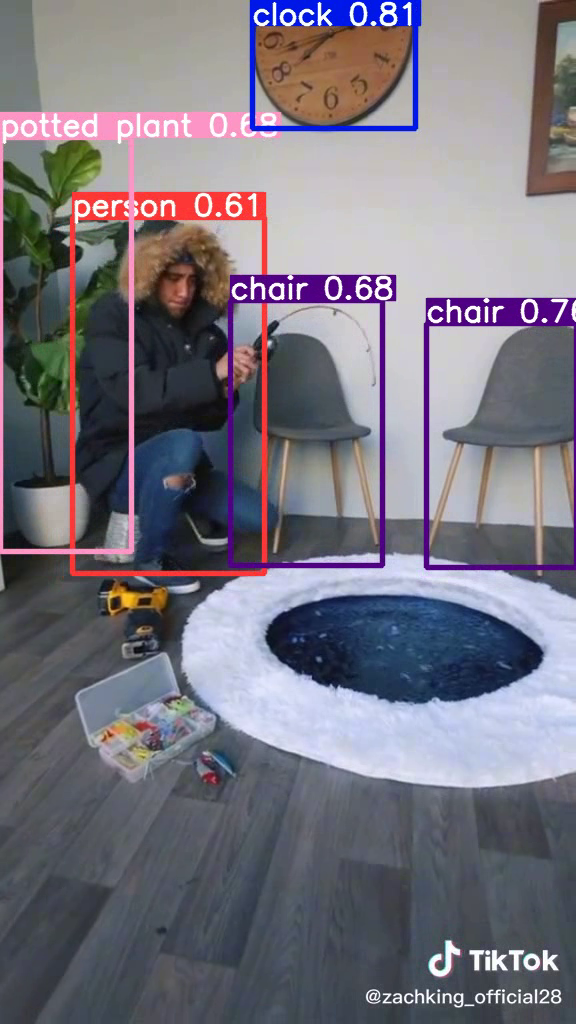

In [8]:
import cv2
from IPython.display import Image

frame_number = 210
filename = f'./{PROJECT}/{NAME}/example.mp4'
cap = cv2.VideoCapture(filename)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
res, frame = cap.read()
cv2.imwrite('frame.png', frame)
Image("frame.png")

In [9]:
def describe_video(PROJECT, NAME):
    """
    This function describe objects that are on the video
    Returns: path to video and its description
    """
    labels_dir = f'{PROJECT}/{NAME}/labels/'
    labels_files = os.listdir(labels_dir)
    
    N = len(labels_files)
    classes = []
    
    for label_file in (labels_files):
        filename = labels_dir + label_file
        with open(filename) as f:
            lines = f.read().splitlines()
            for line in lines:
                class_ = int(line.split(' ')[0])
                classes.append(class_)

    # the class is assigned to the video if the object appears on more than 50 video frames (more than 2 seconds)
    # you may change NUMBER_OF_APPEARANCES to have different duration in filter
    common_classes_in_video = set([i for i in set(classes) if classes.count(i) > NUMBER_OF_APPEARANCES])
    
    classes_in_video = []
    for i in set(common_classes_in_video):  
        classes_in_video.append(model_classes[i])
        
    description = f"video {VIDEO} is about: {', '.join(classes_in_video)}"
    print(description)
    description = {'path': VIDEO, 'description': ', '.join(classes_in_video)}
    return description

In [10]:
video = describe_video(PROJECT, NAME)

video example.mp4 is about: person, potted plant, chair, cup, clock, dining table


In [11]:
video['path']

'example.mp4'

In [12]:
video['description']

'person, potted plant, chair, cup, clock, dining table'

In [13]:
import cv2
from IPython.display import Image

src = 'https://v16-webapp.tiktok.com/f39710e1a04f7a14ddce05cd687d5074/62db64a5/video/tos/useast2a/tos-useast2a-ve-0068c001/9ae8a6d66bed48d992d6b4cd12752f03/?a=1988&ch=0&cr=0&dr=0&lr=tiktok_m&cd=0%7C0%7C1%7C0&cv=1&br=2108&bt=1054&btag=80000&cs=0&ds=3&ft=eXd.6Hm9Myq8Z_vBnwe2NIvhml7Gb&mime_type=video_mp4&qs=0&rc=NGk2Zjc6ZTdnOzU6NjQzaEBpank2ZDY6ZjZrNjMzNzczM0AxXl5gXi0vXmAxMDU0MS82YSNhbjVscjRfbWdgLS1kMTZzcw%3D%3D&l=20220722210128010251069178192145C2'
filename = 'funny_ending.mp4'
_ = urlretrieve(src, filename)

frame_number = 1560
cap = cv2.VideoCapture(filename)
cap.set(cv2.CAP_PROP_POS_FRAMES, frame_number)
res, frame = cap.read()
_ = cv2.imwrite('frame.png', frame)

In [14]:
!python $DETECT --source frame.png

detect: weights=yolov5/yolov5s.pt, source=frame.png, data=yolov5/data/coco128.yaml, imgsz=[640, 640], conf_thres=0.25, iou_thres=0.45, max_det=1000, device=, view_img=False, save_txt=False, save_conf=False, save_crop=False, nosave=False, classes=None, agnostic_nms=False, augment=False, visualize=False, update=False, project=yolov5/runs/detect, name=exp, exist_ok=False, line_thickness=3, hide_labels=False, hide_conf=False, half=False, dnn=False
YOLOv5 🚀 v6.1-312-gb92430a Python-3.7.12 torch-1.11.0 CUDA:0 (Tesla P100-PCIE-16GB, 16281MiB)

Fusing layers... 
YOLOv5s summary: 213 layers, 7225885 parameters, 0 gradients
image 1/1 /kaggle/working/frame.png: 640x384 1 person, 1 carrot, 1 dining table, Done. (0.011s)
Speed: 0.4ms pre-process, 10.6ms inference, 1.2ms NMS per image at shape (1, 3, 640, 640)
Results saved to yolov5/runs/detect/exp


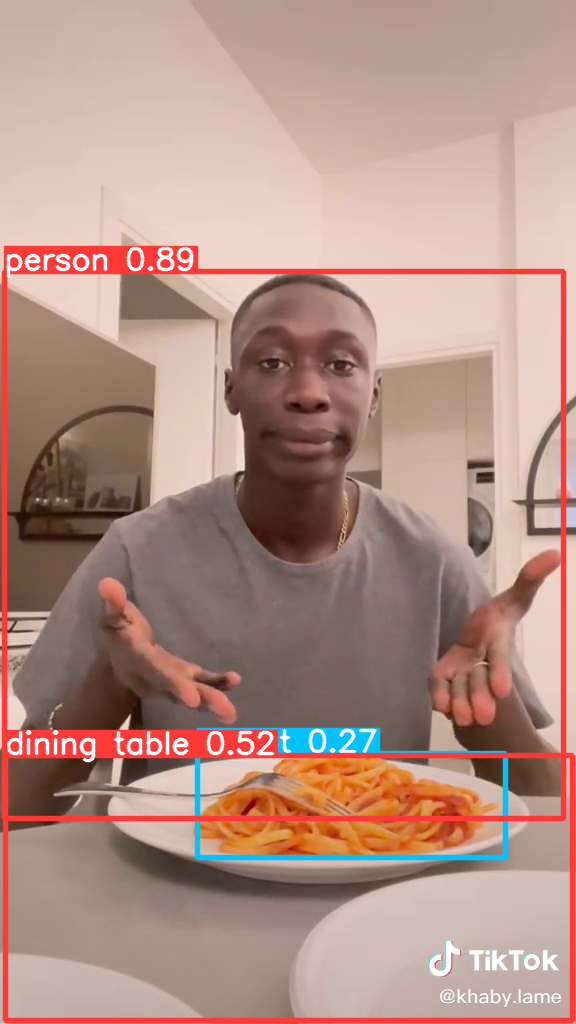

In [15]:
Image('yolov5/runs/detect/exp/frame.png')